We have to find the value for the employed state to perform the backwards induction. 

It is basically a cake eating problem where the remaining cake grows with a given rate and an absolute factor too. 
$A' = (1+R)(A+w-c)$

And the the bellman equation is: 
$V(A) = max_{c \in A+w} ln (c) + \beta   V [(1+R)(A+w-c)]  $ \\

Where we can substitute $c = w + A + A' / (1+R) $ to get: \\

$V(A) = max_{0 \le A' \le A+w} ln (w + A + A' / (1+R)) + \beta   V ( A' )  $

Which is a problem solely with A, that is given and A´ which is the optimizing factor. 

In [237]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt

Første problem er: Hvordan laver vi gridet, så det passer til at A' kan være større end A? 
Bertel har svaret. Det skal vi faktisk slet ikke tænke på, vi skal bare kunne ekstrapolere fra hver initial asset værdi. 
Husk: Vi forholder os altid kun til nuværende periode + næste fremtidige periode. Vi skal ikke forholde os til det scenarie, at opsparing vokser uendeligt
fordi vi kun løser nu og i morgen. 

In [101]:
from scipy import interpolate  # Interpolation routines
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, beta=0.9, abar=[0, 20], n_a=50, n_c=100, w=15, R = 0.05 ):
        """Initializer"""
        self.beta = beta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i], n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 

        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+R)       # vi laver a1 som funktion af hvad du forbruger     'a' er en 1 x n_a vektor
        V = interp(a1)                              # a1 bliver en n_a x n_c matrix     V svarer til de 100 forskellige niveauer af nytte i næste periode
                                                    # a1 er en funktion af c (de andre er faste), så får vi en værdi som ligger mellem grid points ved at interpolere.
                                                    # der er ikke noget med nytte. Er det med vilje fordi den endelige værdi af V altid være den som maksimerer nytten?
        matV1 = np.log(self.c) + self.beta * V      # c er en n_a x n_c vektor   a er en na x 1 vektor a1 bliver så en n_a x n_c matrix. Det gør V så også 
                                                    # så her lægges en n_a x n_c matrix til en n_a x n_c matrix, hvilket giver en n_a x n_c matrix.
        i_max = np.argmax(matV1, axis=1)            # vi kigger på den kolonne som giver den højeste nytte for hver række. n_a x 1 matrix
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # Her går den igennem alle n_a rækker, og finder den kolonne i hver række, som giver den højeste værdi. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser, hvad det optimale forbrug så viste sig at være. 

        return V1, c1
    

Nu tilføjer vi value function solve mekanismen. 

In [141]:
def vfi(self, maxiter=1000, tol=1e-10, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1

# Add the vfi_solve method to the cake_stochastic class
ss_value.solve = vfi

Vi vil gerne have værdierne de endelige værdier ud for hver starting asset value. 

Vi kan lave den her for at man får et job og for hvis man aldrig nogensinde får et job. 
Den eneste ting som skal ændres der er så w. 

In [364]:
emp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=100, w=10, R=0.05)
V_emp, c_emp = emp.solve()

uemp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=100, w=5, R=0.05)
V_uemp, c_uemp = uemp.solve() 



Optimal consumption of assets solved in 465 iterations, using 0.06532 seconds
Optimal consumption of assets solved in 458 iterations, using 0.04894 seconds
(50,)


Optimal consumption of assets solved in 468 iterations, using 0.08453 seconds
Optimal consumption of assets solved in 455 iterations, using 0.06409 seconds


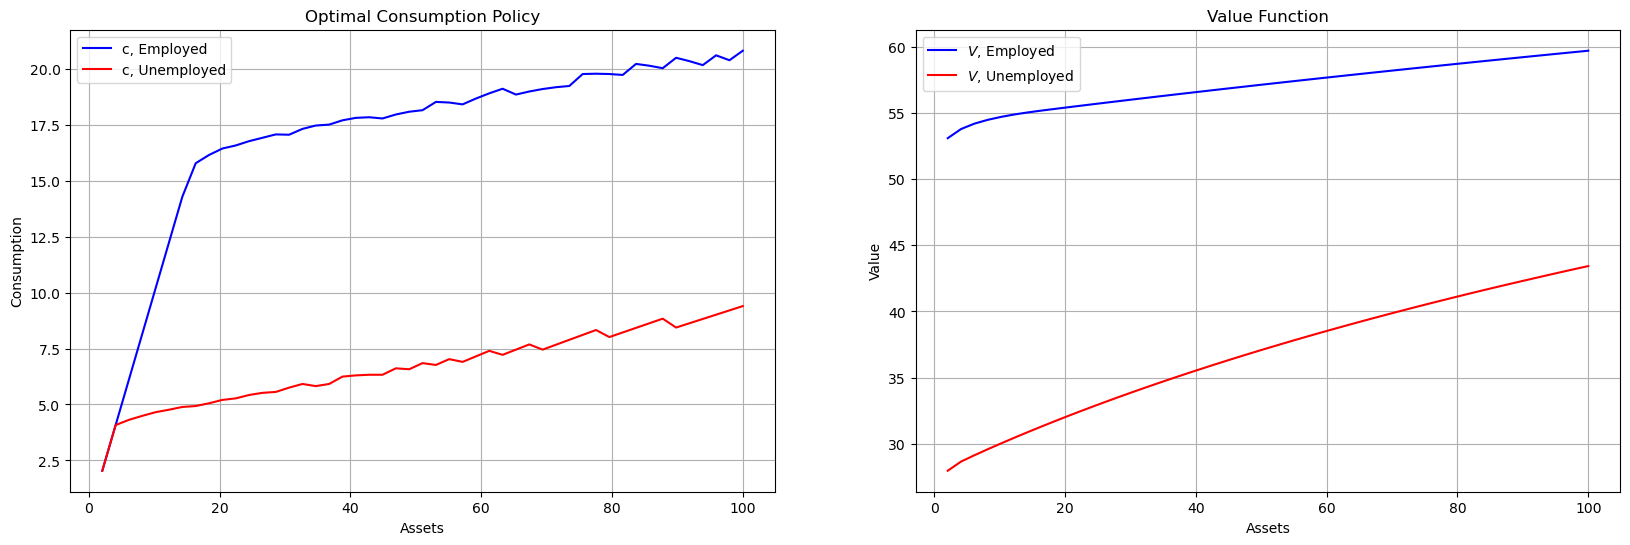

In [214]:
# vi laver plot for value og consumption rule for dem som ender i SS med arbejde og dem som ender i SS uden arbejde.
# vi kan også lave et plot for forskellige lønninger

emp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=15, R=0.05)
V_emp, c_emp = emp.solve()

uemp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=4, R=0.05)
V_uemp, c_uemp = uemp.solve() 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.grid(True)
ax2.grid(True)
ax1.plot(emp.a[1:], c_emp[1:], color="b", label="c, Employed")
ax1.plot(emp.a[1:], c_uemp[1:], color="r", label="c, Unemployed")
ax1.set_xlabel("Assets")
ax1.set_ylabel("Consumption")
ax1.legend()
ax1.set_title("Optimal Consumption Policy")
ax2.plot(emp.a[1:], V_emp[1:], color="b", label="$V$, Employed")
ax2.plot(emp.a[1:], V_uemp[1:], color="r", label="$V$, Unemployed")
ax2.legend()
ax2.set_title("Value Function")
ax2.set_xlabel("Assets")
ax2.set_ylabel("Value")
plt.show()

Consumption burde jo ikke variere på den måde, men i stedet være roligt voksende funktioner. 

------------------------------------------------------------------------------------------------------------------------------------------------

Nu har vi steady state værdierne for nytte i evigheden givet asset values i sidste periode. 

Den præcist samme metode som ovenfor kan bruges til at finde nytten af unemployment. Vi skal blot indsætte en anden værdi af w.

Ud fra det kan vi vise i ovenstående plots, hvor meget nytten og forbruget ændrer sig ved at have et job og ikke have et job. 

Dem skal vi bruge til at løse det optimale forbrugsproblem via backwards induction.  

At løse det for arbejdet er det mindst komplicerede, fordi lønnen er konstant over hele perioden. 

Vi skal kun bruge 6 perioder. Én periode som er den sidste inden vi kigger efter steady state værdierne. 5 perioder, hvor agenten tilpasser sit referencepunkt til seneste periodes indkomst. 

Hvad skal vi bruge? 

1. Den nye nyttefunktion med et loss parameter. 
2. Referencepunktet for seneste periode.
    Det kan vi måske finde gennem income paths? 
3. Terminalværdien i sidste periode. Som er det vi har fået fra VFI. 
4. Derfra skal vi blot løse BI problemet. Det burde være helt okay. 

Nu ender vi et problem. vi skal bruge referencen fra seneste periode og nytteværdien for fremtidige periode... 

In [342]:
class ref_inc_path():
    def __init__(self,w =15, b1=10, b2 = 8, b3 = 6, welfare = 4, T1 = 12, T2 = 36, T3 = 48, T = 54, N = 5, eta = 1 ):
        self.w = w              # Løn
        self.b1 = b1            # højeste dagpengesats    
        self.b2 = b2            # næste dagepengesats
        self.b3 = b3            # laveste dagpengesats
        self.welfare = welfare  # 'kontanthjælp'
        self.T1 = T1            # periode til højeste dagpengesats
        self.T2 = T2            # periode til næste dagpengesats
        self.T3 = T3            # periode til laveste dagpengesats
        self.T = T              # periode til kontanthjælp
        self.N = N              # antal referenceperioder
        self.eta = eta          # det er for at kunne modificere løsningen til også at være ikke reference-dependent

    def benefit_path_(self):                # vi laver income paths som en T, array med alle income levels for forskellige perioder
        '''
        Returns the benefit path given parameter values.
            Arguments:
                b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
                T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
                T (int): Total number of periods
            Returns:
                benefits (array): Benefit path in unemployment
        '''
        benefits        = np.zeros(self.T)       # Laver en vektor med T, elementer. 
        benefits[0:self.T1]  = self.b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
        benefits[self.T1:self.T2] = self.b2
        benefits[self.T2:self.T3] = self.b3
        benefits[self.T3:self.T]  = self.welfare

        return benefits
    
    def income_path_(self):                          
        '''Laver alle de mulige income paths. 
            En for alle tidspunkter hvorpå man finder et job, inklusiv muligheden for aldrig at finde et job
        '''
        benefits = self.benefit_path_()
        income_path = np.tile(benefits,(self.T+1,1))
        for j in np.arange(self.T): 
            income_path[j,j:] = self.w
        return income_path
    
    def ref_path_(self):             # the reference point is given as the arithmetic average of the income in the 5 periods leading up to the current one. 
        if self.eta > 0: 
            ref_path = np.zeros((self.T+1, self.T))
            income_path = self.income_path_()
        
            for t in np.arange(self.T): 
                if t == 0:
                    ref_path[:,t] = self.w         # vi antager at lønnen før og lønnen efter bistand er den samme. 

                if t > 0: 
                    N_pre = max(self.N - t, 0)  # vi sætter antal perioder med løn til at blive mindre, når man har været længere tid på DP. Indtil løn slet ikke indgår i referencen. 
                    '''Her modificerer jeg koden ned i kompleksitet, så vi ikke tager højde for eventuelle halve perioder. 
                    Da vi slet ikke har dem med. Se rdmodel.py, for den komplekse udgave'''
                    start = max(t-self.N, 0)
                    end = t
                        #Her laver vi summen / gennemsnittet. 
                        #Når t > 4 så betyder N_pre leddet ikke længere noget.
                    ref_path[:,t] = ( N_pre*self.w + np.sum(income_path[:,start:end], axis = 1, keepdims=False ) ) / self.N
            
                    # reference path tager gennemsnittet for de seneste fem perioder af indkomst for alle rækker i income path.
                    # så altid summen af de t-5 til t søjler i income path plus evt. led fra før dagpenge, hvis vi er i t < 5
                    # axis = 1 betyder at vi kigger på søjler keepdims = False betyder at vi kun returner en vektor med t værdier pr. række.
                    # så hver række i income path repræsenterer, hvornår man får job. Hver række i r repræsenterer den dertilhørende lønreference i alle perioder. 
        else: 
            ref_path = self.income_path_()    
            
        return ref_path
         
        
    def ref_path_long_(self):        # we create this to get the future values of ref-dependence when getting a job inside T-N last periods.
            
        add = np.zeros( (self.T+1, self.N)  )

        ref_path = self.ref_path_().reshape(55,54)
        ref_path_long = np.concatenate((ref_path, add), axis = 1)      # now we add N columns to the ref_path_
            
        income_path = self.income_path_()       # we add the income path to use it later

        for t in np.arange(self.T, self.T + self.N):
                
            start = min ( t - self.N , self.T)      # vi definerer start som den periode vi er i og minus de N perioder vi kigger tilbage. Vi går indtil sidste periode i income_path
            end = self.T                            # det her er måske overflødigt, fordi vi bare siger, at vi stopper ved enden. 

            ref_path_long[:,t] = (  np.sum(income_path[:,start:], axis = 1, keepdims=False     )   + (t-self.T)* self.w ) / self.N 
                                        # so what the code does is that it takes the sum of the last periods available in the income path
                                        # plus the sum of the periods not available and divides by N to get the average.  
            
        return ref_path_long
               

In [361]:
model = ref_inc_path(w =15, b1=10, b2 = 8, b3 = 6, welfare = 4, T1 = 12, T2 = 36, T3 = 48, T = 54, N = 5, eta = 1 )

ref_path_long = model.ref_path_long_()

print(ref_path_long[54,50:])        # this is getting the job in period T + 1 that's why it doesn't converge. 
print(ref_path_long.shape)

[ 5.2  4.8  4.4  4.   4.   6.2  8.4 10.6 12.8]
(55, 59)


Nu gør vi det samme som artiklen og finder værdien af VE i alle perioder for alle asset levels. 

Nu har vi alle mulige income paths og vi har reference indkomsten for alle income paths

Så vi skal bruge bellman equation i finite horizon
Derfor skal vi have nytten
- herunder leddet med gain-loss.


Nu skal vi løse værdien af at have et job ved at tage de optimale forbrugsvalg i perioden efter, at man har fået et job. 
Det er det følgende maksimeringsproblem. 

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + \eta \left( u[w+A_t + \frac{A_{t+1}}{1+R}] - u[r_t]  \right)  + V(A_{t+1})    $ 

Hvilket vi kan skrive om til: 

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } (1+\eta) u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + k   + V(A_{t+1})    $ 

Hvor $k = - \eta \cdot u[r_t]$, da k er eksogent givet af t. 


In [227]:
V_ss = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=15, R=0.05)        # her kan vi godt kalde dem Vss_e og Vss_u
V_ss, C_ss = np.array( V_ss.solve() )                                           # når vi ændrer mellem emp og uemp så er det kun lønnen i perpetuiteten vi ændrer

print(V_ss.shape)

Optimal consumption of assets solved in 468 iterations, using 0.08639 seconds
(50,)


Nedenstående kode finder værdien af at få et job i alle perioder for alle asset values. 
Den er grundlæggende lidt klodset, fordi vi blot kunne have brugt 'reference_path_long', men jeg var lidt i tvivl om min freestyle var en god ide
så jeg har beholdt begge dele, så vi altid kan slette det igen. 
_________________________________________________________________________________________________________________________________________________

Men det er også forkert fordi, at det ikke tager højde for det man kan vinde ved at bruge af sin opsparing tidligt, når ens reference punkt er lavt. 

In [ ]:
# Vi skal lave en funktion for nytten af alle perioderne. Det gør vi ved, at tage nytten ud i uendeligheden og så tilføje gain-loss i alle perioderne. 
# Når vi får et job, så skal vi ikke tænke over loss-delen, fordi indkomsten altid vil være mindst stigende ift. referenceperioden. 

def v(c): 
    return np.log(c)

def value_emp(T,N,w,eta, delta,ref_path,ref_path_long):
    V_E = np.tile(V_ss[:,None],T)           # den her matrice replikerer ss værdien af job for alle asset values i alle perioder. Asset values er rækker. Tidspunkt er kolonner. 
                                            # nu skal vi tilføje gain-loss delen ud af tidsperioderne. 
    for t in np.arange(T-N):

        # Add gain-loss part
        for i in np.arange(N):
            V_E[:,t] = V_E[:,t] + eta * delta**i * (v(w) - v(ref_path[t,t+i])  )        
            # Hver iteration tilføjer værdien af gain-loss leddet af at få jobbet i periode t ved at kigge på ref-perioden for den relevante række(tidspunkt, hvor man får jobbet) 
            # plus de relevante efterfølgende i = N perioder referencepunkter. 
            # Den tilføjer den til hver række (asset level) på den tilhørende kolonne. 
            # den endelige matrice har værdien af at få job i periode 1 i for alle asset levels i kolonne 1. Værdi af job for alle asset levels i periode 2 i kolonne 2 osv. 
    
    for t in np.arange(T-N,T):              # now we look at the last N periods, where the ref will go out of bounds. 
        for i in np.arange(N):              # but it doesn't because we added a longer reference path, so it is basically the same as above     
             V_E[:,t] = V_E[:,t] + eta * delta**i * (v(w) - v(ref_path_long[t,t+i])  )     
                                                                                    
        V_E[:,t] = V_E[:,t]

    return V_E

"The value of employment rises in every period, because we look at the value evaluated at time t"
"This means that we disregard the discount value of future periods (except for the five periods after job finding)"
"The reason that the value of job is higher is because the reference point gets lower for every period. Thus the gain loss part is higher"

"The matrix must be understood as row 0 = for asset value 0 what is the value of job in period 0,1,2,...,T"
"Row 1 = for asset value 1 what is the value of job in period 0,1,2,...,T"



In [360]:
V_E = value_emp(T = 54, N = 5, w = 15, eta = 1, delta = 0.95, ref_path = ref_path, ref_path_long = ref_path_long)

print(V_E.shape)
print(V_E[0,:])


(50, 54)
[16.3329035  16.64505356 16.91998487 17.14830669 17.31797888 17.41328906
 17.41328906 17.41328906 17.41328906 17.41328906 17.41328906 17.41328906
 17.41328906 17.57030209 17.70873425 17.82401287 17.91012195 17.95891212
 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212
 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212
 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212 17.95891212
 17.95891212 18.13847415 18.30069491 18.43994182 18.54807634 18.61261486
 18.61261486 18.61261486 18.61261486 18.61261486 18.61261486 18.61261486
 18.61261486 18.82571683 19.02449214 19.20241763 19.34882335 19.44413353]


Nu da vi har værdien af at finde et job i alle perioder fra 0 til T og vi har den værdi for alle asset-værdier, kan vi løse for den optimale allokering af assets. 

Husk at det her er værdien af at finde et job i periode t. Ikke værdien af at have jobbet. 

Så det vil sige, at vi ikke kan bruge den matrix til at hoppe fra asset level til asset level i næste periode... 

-------------------------------------------------------------------------------------------------------------------------------------

Da det optimale valg af $A_{t+1}$ er uafhængigt af $r_t$ (se nedenfor) så skal vi faktisk løse backwards induction problemet for forbrug og derefter kan vi tilføje gain-loss nytten, for at finde den endelige nytte af at få et job i alle perioder. 

Nytten af at få et job i en bestemt periode er altså givet ved den SS-value man ender på med sine valg plus forbruget i perioderne op til, at man ender der.

$   V(A_t) = max _{0 \le A_{t+1} \le A_t } (1+\eta) u \left(w+A_t + \frac{A_{t+1}}{1+R} \right) + k   + V(A_{t+1})    $ 

Hvor $k = - \eta \cdot u[r_t]$, da k er eksogent givet af t. 



In [370]:
from scipy import interpolate  # Interpolation routines
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, beta=0.9, abar=[0, 20], n_a=50, n_c=100, w=15, R = 0.05 ):
        """Initializer"""
        self.beta = beta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i], n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 

        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+R)       # vi laver a1 som funktion af hvad du forbruger     'a' er en 1 x n_a vektor
        V = interp(a1)                              # a1 bliver en n_a x n_c matrix     V svarer til de 100 forskellige niveauer af nytte i næste periode
                                                    # a1 er en funktion af c (de andre er faste), så får vi en værdi som ligger mellem grid points ved at interpolere.
                                                    # der er ikke noget med nytte. Er det med vilje fordi den endelige værdi af V altid være den som maksimerer nytten?
        matV1 = np.log(self.c) + self.beta * V      # c er en n_a x n_c vektor   a er en na x 1 vektor a1 bliver så en n_a x n_c matrix. Det gør V så også 
                                                    # så her lægges en n_a x n_c matrix til en n_a x n_c matrix, hvilket giver en n_a x n_c matrix.
        i_max = np.argmax(matV1, axis=1)            # vi kigger på den kolonne som giver den højeste nytte for hver række. n_a x 1 matrix
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # Her går den igennem alle n_a rækker, og finder den kolonne i hver række, som giver den højeste værdi. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser, hvad det optimale forbrug så viste sig at være. 

        return V1, c1
    
model = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=15, R=0.05)        # her kan vi godt kalde dem Vss_e og Vss_u


' det her laver jeg kun lige for at minde mig selv om at V1 er en n_a x 1 vektor. '
V1, c1 = model.bellman(R = 0.05, V0 = np.log(model.a[:, 0]) )
print (V1.shape)


(50,)


Ovenstående kode kan vi bruge. Vi skal dog modificere den, så den også indeholder reference path. 

----------------------------------------------------------------------------------------------------------------

Nedenstående er en skitste. Jeg vil gerne skrive den ind i en class, men det kan jeg ikke førend, at jeg har AI tilbage igen. 

In [ ]:


#sygt meget af det her kan vi jo definere inden funktionen... det er lidt dumt, vi burde kunne lave et langt stykke pænt kode, hvor man ikke hele tiden skal definere de samme ting igen og igen ogn igen.

def bellman(V_ss, ref_path, beta, eta, R, w, abar, T, N, n_a, n_c ): 
    
    ''' her så laver vi den som den altid vil se ud i sidste periode '''
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1)) # vi laver a fra 0 til maks værdien. 
    
    c = np.empty((n_a, n_c))
    for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            c[i, :] = np.linspace(abar[0], a[i], n_c).reshape((1, n_c)) 

    interp = interpolate.interp1d(a[:, 0], V_ss, bounds_error=False, fill_value="extrapolate")
    V = 0
    a1 = (a-c+w)*(1+R)
    V = interp(a1)          # i den sidste periode, så er det her rigtigt. Fordi vi interpolerer over mulighederne for nytte ved asset values til sidst
                            # det er bare ikke rigtigt i perioderne inden, for der har vi gain-loss delen at kigge på også. 
    
    ''' herfra skal vi lave et loop, som bruger værdierne for den endelige periode og vi looper over, hvornår man får jobbet, så vi kan bruge ref_path '''
    for j in np.arange(T+1): 
        for n in np.arange(N): 
            matV1 = np.log(c) + eta * ( np.log(c)-np.log(ref_path[j,j+n]) ) + beta * V         # her tager den altid og kigger på den rigtige job periode og det rigtige referencepunkt.
                                # men hvordan fungerer det med c og V                                       fordi vi har skrevet (j,j+N)
                                # det er jo egentlig bare det samme som før, men nu gør vi det for alle perioder, hvor man kan få et job. 
            i_max = np.argmax(matV1, axis=1)            # vi finder den kolonne i matV1 som giver den højeste nytte for hver række. 
            V1 = matV1[np.arange(n_a), i_max]      # her finder vi så værdien af det forbrug som giver den højeste nytte for hver asset value. 
            c1 = c[np.arange(n_a), i_max]                                            # det er en n_a x 1 vektor. 

    return V1, c1      # det er vigtigt at return ligger herinde, så vi rent faktisk får klargjort alle værdierne.    
    
    # så hvis den her kode virker så får vi T+1 x 2 matricer ud med arrays på n_a x 1  
    
    # hvad skal vi så bruge dem til? Jo, så har vi for alle tidspunkter, hvor man kan få et job fundet ud af, hvad der er bedst at gøre lige inden man overgår til ss-værdien. 
    # den værdi skal vi så bruge til at løse problemet én periode tidligere. 
    # Husk: når du kigger på definitionen af matV1 kan du se, at det er altså den optimale værdi af nytten for forbrug i dag plus value for ever.  

'Remember that in the ref path the rows is when you get the job'
'Going all the way to T+1 for not ever getting the job'   
'So looking at the j,j element of the ref path is always looking at the reference point when getting the job'
' but we are here looking at the last period before you enter the steady state, so we have to look at j+n column '
' exactly this. If one more then we are two times in the infinity period '


# det næste, som skal ske er, at vi bruger value function, som vi har fundet her og indsætter i periode j, j+N-1
# fordi man har stadig fået jobbet i samme periode, men nu skal man bare løse problemet én periode tidligere, hvor ens referenceindkomst er én periode tidligere. 
hej = bellman( V_ss = V1 , ref_path = ref_path, w = 15, R = 0.05, beta = 0.95, eta = 1, T = 54, N=5, n_a = 50, n_c = 100, abar = [0,20] )
print(V1)


So below is what Claude made from your initial code. After Hans go look at this. 

Hvad er det Claude har gjort, som jeg ikke gjorde, og som gør at det virker? 

1. Den har lavet en placeholder vektor inden loopet. Det er smart at gøre fremover også, så loopet kan fylde værdierne stille og roligt. 
2. Den introducerer først steady state værdien inden i loopet. 
3. Den skriver også den nye værdi i slutningen af loopet, så den langsomt bliver opdateret. Så tilføjer den først 'return' statement bagefter. 

In [402]:
def employment_BI(V_ss, ref_path, beta, eta, R, w, abar, T, N, n_a, n_c):
    abar[0] = np.maximum(np.finfo(float).eps, abar[0])              # vælger numerisk nul, så vi kan tage log. 
    a = np.linspace(abar[0], abar[1], n_a).reshape((n_a, 1))        # laver en n_a x 1 matrice med værdierne fra 0 til maks asset level. 

    c = np.empty((n_a, n_c))    # For hver state kan man vælge n_c forskellige niveauer af forbrug i perioden
    for i in range(n_a):        # vi kigger på alle rækkerne og tilføjer forbrugsmuligheder fra 0 og op til maks forbrug som er givet ved assets + løn.  
        c[i, :] = np.linspace(abar[0], (a[i]+w), n_c).reshape((1, n_c))     # Laver det om til en vektor med 1 række og n_c kolonner. 

    a1 = (a - c + w) * (1 + R)   # assets i næste periode

    V_out = np.zeros((T+1, n_a))   # placeholder variable for getting the job in period in period T with asset value a. 
    c_out = np.zeros((T+1, n_a))   # associated optimal consumption, first period after job start, not really that relevant though...

    for j in np.arange(T+1):
        V0 = V_ss   # steady state value from the value function iterations. 

        # step backward: n = N-1 (period closest to steady state) down to n = 0 (period job starts)
        for n in np.arange(N-1, -1, -1):
            interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")    # here it always takes the latest V0 value, so a new one in every period. This is where the updated values get used. 
            V_next = interp(a1)     # V_next er jo altid den seneste værdi. Første del af loopet er så den 'interpolerede' værdi fra v_ss af givne asset levels mellem grids. 

            matV1 = np.log(c) + eta * (np.log(c) - np.log(ref_path[j, j+n])) + beta * V_next    # nytteværdi for givet 'j' jobtidspunkt for n-perioder efter job er fundet. 
                                                            # og så fordi at c er defineret som alle forbrugsmuligheder med forskellige asset levels overholdet det budget begrænsningen. 
            i_max = np.argmax(matV1, axis=1)                # hvordan overholder vi budgetbegrænsningen i næste periode? 
            V0 = matV1[np.arange(n_a), i_max]               # her opdateres værdierne givet det optimale forbrugsval. Det bliver så genbrugt til næste periode. 
            c_current = c[np.arange(n_a), i_max]

        V_out[j, :] = V0
        c_out[j, :] = c_current

    return V_out, c_out

Her får vi værdierne. c_out er lidt ligemeget, fordi det er den endelige c-værdi, hvilket vi egentlig ikke skal bruge. Altså, vi tracker slet ikke på den her måde den rigtige consumption path, men kun den sidste værdi. Vi skal heller ikke rigtigt bruge den, men hvis vi vil, så har claude lavet et udkast til kode for det her. 

In [ ]:
c_out = np.zeros((T+1, N, n_a))   # store policy for every period n, not just n=0

for j in np.arange(T+1):
    V0 = V_ss
    for idx, n in enumerate(np.arange(N-1, -1, -1)):
        interp = interpolate.interp1d(a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V_next = interp(a1)
        matV1 = np.log(c) + eta * (np.log(c) - np.log(ref_path[j, j+n])) + beta * V_next
        i_max = np.argmax(matV1, axis=1)
        V0 = matV1[np.arange(n_a), i_max]
        c_out[j, idx, :] = c[np.arange(n_a), i_max]   # save this period's policy

    V_out[j, :] = V0

Så her kommer værdierne faktisk først. 

In [403]:
V_out, c_out = employment_BI(V_ss = V1 , ref_path = ref_path_long, w = 15, R = 0.05, beta = 0.95, eta = 1, T = 54, N=5, n_a = 50, n_c = 100, abar = [0,20] )

print(V_out[54,:])       # kolonnerne er asset levels
                        # rækkerne er tidspunkter at få jobbet på
                        
                        # det kan vi se her fordi at der sket et rigtig stort spring fra asset level 0 til 1. Ikke længere faktisk, fordi der nu kommer en løn. 
                        # Hvilket kommer af nytten fra logaritmen til approksimativt 0 er næsten minus uendelig. 

print(V_out[:,49])       # vi kan også se det ved det her print, hvor nogle af værdierne er ens fordi personerne når at tilpasse sig de nye lavere niveauer af indkomst. 
                        
# vi kan også bare se det ved at kigge på shape, hvor der er 50 asset levels og 54+1 tidsperioder. 
print(V_out.shape)

Okay, så nu har vi den samlede værdi af at få et job i alle perioder for alle asset levels. Det kan altid ændres ved blot at ændre entry værdierne i vores funktioner. 
Koden er stadig lidt rodet, men det kan vi godt få lavet om på. 

Nu skal vi til at finde nytten for ikke at have et job, så vi kan sammenligne de to nytter og dermed vælge den optimale search effort. 
Vi har allerede nytten ved ikke at have job i alt uendelighed, fordi det finder vi ved value function iterations ligesom, hvis man har et job. 

In [ ]:
# vi skal bruge koden som laver 'inverse prime' for search cost. 
